✅ NLTK loaded
✅ WordCloud + Matplotlib loaded

  STEP 1: Loading campus_data.txt
  Raw lines loaded        : 2140
  Total raw characters    : 354,103

  STEP 2: Identifying source sections in the file
  Source_A_Academic_Regulations          → 4 lines
  Source_B_CSE_Department                → 41 lines
  Source_C_Course_Syllabi                → 335 lines
  Source_D_Research_Projects             → 140 lines
  Source_E_Compute_Resources             → 25 lines
  Source_F_News_Announcements            → 1595 lines

  STEP 3: Defining preprocessing pipeline
  Preprocessing function defined ✅
  Steps applied per line:
    (i)   Boilerplate removal  — URLs, emails, markdown, codes
    (iii) Lowercasing
    (iv)  Punctuation removal  — keep only a-z letters
    (ii)  Tokenization         — NLTK word_tokenize / split

  STEP 4: Preprocessing all sources
  ✅ Source_A_Academic_Regulations
       raw lines → 4, sentences kept → 1, tokens → 199
  ✅ Source_B_CSE_Department
       raw lines → 41, sen

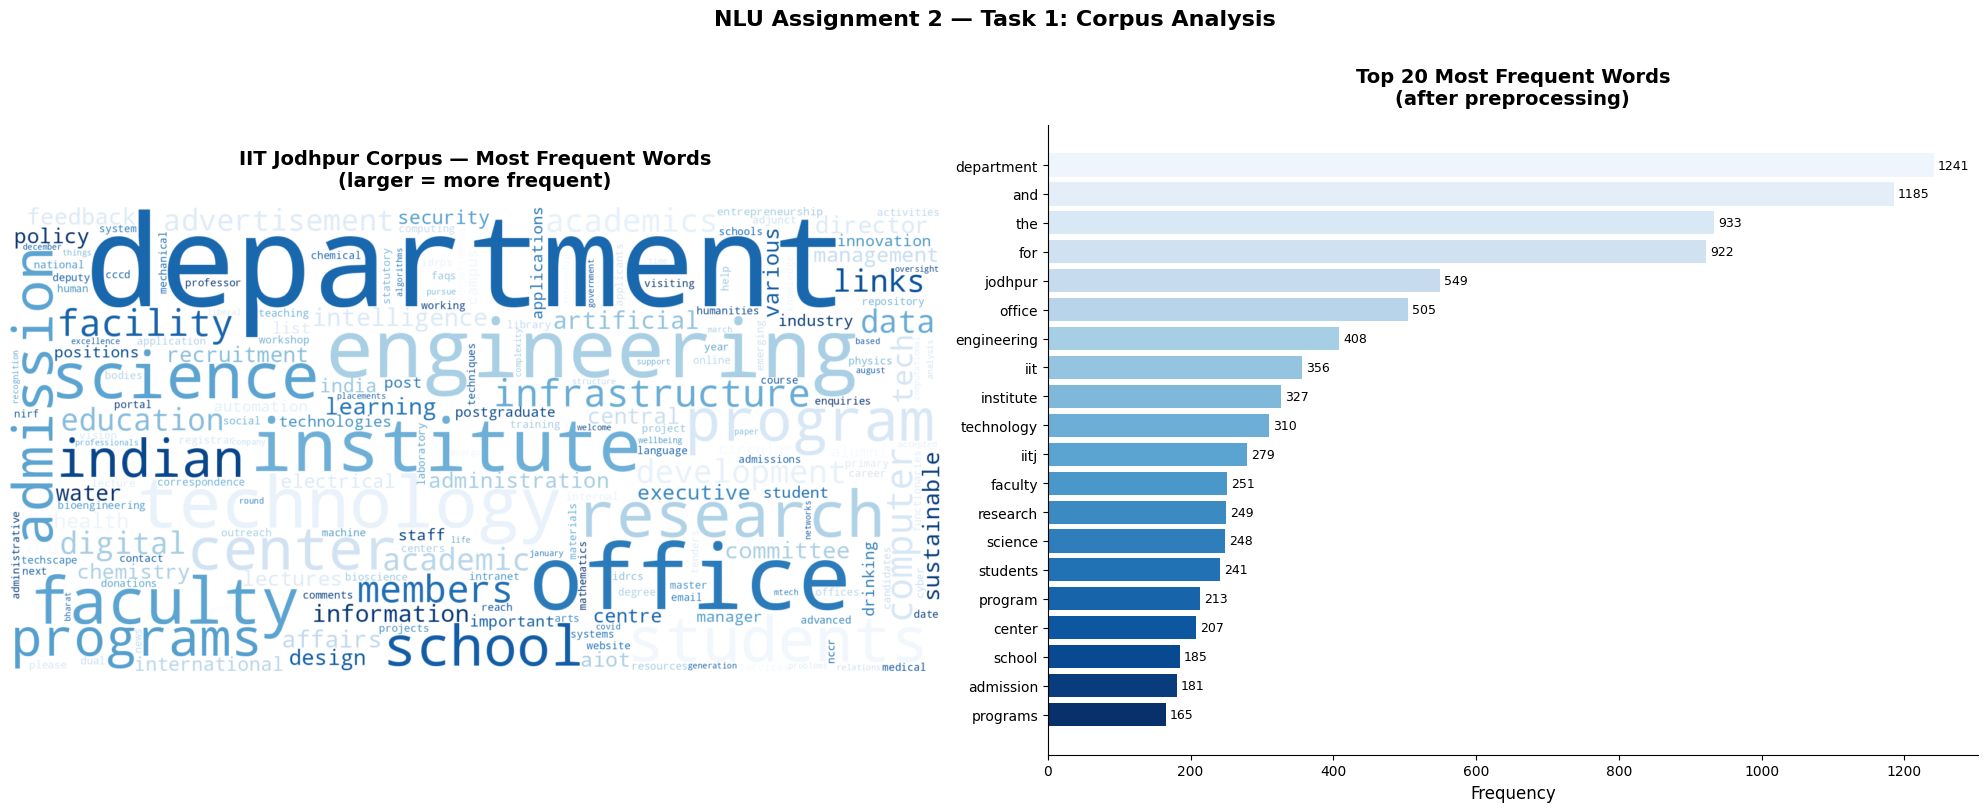

  ✅ Saved: outputs/wordcloud.png

  ✅  TASK 1 COMPLETE — All deliverables generated

  Output files (check your outputs/ folder):
  ┌─────────────────────────────────────────────┐
  │  cleaned_corpus.txt    ← submit this        │
  │  cleaned_sentences.txt ← used in Task 2     │
  │  dataset_statistics.txt← paste in report    │
  │  wordcloud.png         ← include in report  │
  └─────────────────────────────────────────────┘

  Key numbers for your report:
  ─────────────────────────────
  Total Documents (sections) : 6
  Total Tokens               : 34,340
  Vocabulary Size            : 3,770
  Total Sentence Units       : 1,781



In [19]:
# ============================================================
# NLU Assignment 2 — Problem 1, Task 1: Dataset Preparation
# File  : task1_complete.py
# Input : campus_data.txt  (IIT Jodhpur scraped corpus)
# Output: cleaned_corpus.txt, cleaned_sentences.txt,
#         dataset_statistics.txt, wordcloud.png
#
# How to run:
#   pip install nltk wordcloud matplotlib
#   python task1_complete.py
# ============================================================

import re
import os
import string
from collections import Counter

# ── Try importing third-party libs; fall back gracefully ────
try:
    import nltk
    # Download required NLTK data (runs only once, cached after)
    nltk.download('punkt',     quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)
    from nltk.tokenize import word_tokenize
    NLTK_AVAILABLE = True
    print("✅ NLTK loaded")
except ImportError:
    NLTK_AVAILABLE = False
    print("⚠️  NLTK not found — using built-in whitespace tokenizer")

try:
    from wordcloud import WordCloud
    import matplotlib.pyplot as plt
    WC_AVAILABLE = True
    print("✅ WordCloud + Matplotlib loaded")
except ImportError:
    WC_AVAILABLE = False
    print("⚠️  wordcloud/matplotlib not found — skipping word cloud image")

# ────────────────────────────────────────────────────────────
# STEP 1 ── LOAD THE RAW FILE
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 1: Loading campus_data.txt")
print("="*55)

RAW_FILE   = "campus_data.txt"   # path to your uploaded file
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Read the whole file as one string
with open(RAW_FILE, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

# Split into lines — each non-empty line is treated as a "document unit"
raw_lines = raw_text.splitlines()
print(f"  Raw lines loaded        : {len(raw_lines)}")
print(f"  Total raw characters    : {len(raw_text):,}")


# ────────────────────────────────────────────────────────────
# STEP 2 ── IDENTIFY DOCUMENT SECTIONS
# The file contains data from multiple IIT Jodhpur sources:
#   Source A  — Academic programmes / regulations (lines 1–4)
#   Source B  — CSE Department info (lines 5–45)
#   Source C  — Course syllabi (lines 46–~300)
#   Source D  — Research projects / faculty (lines ~300–520)
#   Source E  — Compute resources (lines ~520–540)
#   Source F  — News & announcements (lines ~540–908)
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 2: Identifying source sections in the file")
print("="*55)

# Boundary markers found by inspecting the actual file content
# We use these to split into logical documents for the assignment
SECTION_MARKERS = {
    "Source_A_Academic_Regulations" : 0,       # line index start
    "Source_B_CSE_Department"       : 4,
    "Source_C_Course_Syllabi"       : 45,
    "Source_D_Research_Projects"    : 380,
    "Source_E_Compute_Resources"    : 520,
    "Source_F_News_Announcements"   : 545,
}

# Build a dict of source_name → list of raw lines
sources = {}
section_names  = list(SECTION_MARKERS.keys())
section_starts = list(SECTION_MARKERS.values())

for i, name in enumerate(section_names):
    start = section_starts[i]
    end   = section_starts[i + 1] if i + 1 < len(section_names) else len(raw_lines)
    sources[name] = raw_lines[start:end]
    print(f"  {name:<38} → {len(sources[name])} lines")


# ────────────────────────────────────────────────────────────
# STEP 3 ── PREPROCESSING FUNCTION
# Applies ALL 4 required steps from the assignment:
#   (i)   Remove boilerplate / formatting artifacts
#   (ii)  Tokenization
#   (iii) Lowercasing
#   (iv)  Remove punctuation and non-textual content
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 3: Defining preprocessing pipeline")
print("="*55)

def preprocess_line(line):
    """
    Cleans a single line of raw text and returns a list of tokens.

    Pipeline:
    ─────────
    1. Remove boilerplate: URLs, emails, markdown links, numbers,
       non-ASCII (Hindi/Devanagari), special symbols, line prefixes
       like "123 .[...]" from the news section
    2. Lowercase
    3. Remove punctuation / non-alpha characters
    4. Tokenize (split into words)
    5. Filter: drop tokens shorter than 2 characters
    """

    # ── (i) Boilerplate removal ──────────────────────────────

    # Extract the TEXT from markdown hyperlinks [Title](URL) before removing
    # e.g., "[PhD Admission at IIT Jodhpur](https://...)" → "PhD Admission at IIT Jodhpur"
    line = re.sub(r'\[([^\]]+)\]\([^)]*\)', r' \1 ', line)

    # Remove any remaining bare URLs  https://... or www....
    line = re.sub(r'https?://\S+|www\.\S+', ' ', line)

    # Remove email addresses  user@domain.com
    line = re.sub(r'\S+@\S+\.\S+', ' ', line)

    # Remove news-list prefixes like "123 ." or "45."
    line = re.sub(r'^\s*\d+\s*\.?\s*', ' ', line)

    # Remove markdown bold markers **text**
    line = re.sub(r'\*+', ' ', line)

    # Remove course codes like CS7xx, CSL7140, L-T-P, [C]
    line = re.sub(r'\b[A-Z]{2,4}\d+[A-Za-z]*\b', ' ', line)
    line = re.sub(r'\d+[-–]\d+[-–]\d+', ' ', line)        # e.g., 3-0-0
    line = re.sub(r'\[\s*\w?\s*\]', ' ', line)             # e.g., [3], [C]

    # Remove non-ASCII characters (removes Hindi / Devanagari etc.)
    line = re.sub(r'[^\x00-\x7F]+', ' ', line)

    # Remove standalone numbers and mixed alphanum codes
    line = re.sub(r'\b\d+\b', ' ', line)

    # ── (iii) Lowercase ──────────────────────────────────────
    line = line.lower()

    # ── (iv) Remove punctuation / non-alpha ──────────────────
    # Keep only a-z letters and whitespace; strip everything else
    line = re.sub(r'[^a-z\s]', ' ', line)

    # Collapse multiple whitespace into a single space
    line = re.sub(r'\s+', ' ', line).strip()

    # ── (ii) Tokenize ────────────────────────────────────────
    if NLTK_AVAILABLE:
        tokens = word_tokenize(line)              # NLTK tokenizer
    else:
        tokens = line.split()                     # simple whitespace split

    # Drop very short tokens (1-2 chars = noise, abbreviation fragments)
    tokens = [t for t in tokens if len(t) > 2]

    return tokens


print("  Preprocessing function defined ✅")
print("  Steps applied per line:")
print("    (i)   Boilerplate removal  — URLs, emails, markdown, codes")
print("    (iii) Lowercasing")
print("    (iv)  Punctuation removal  — keep only a-z letters")
print("    (ii)  Tokenization         — NLTK word_tokenize / split")


# ────────────────────────────────────────────────────────────
# STEP 4 ── APPLY PREPROCESSING TO ALL SOURCES
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 4: Preprocessing all sources")
print("="*55)

all_tokens    = []     # flat list of every token across all sources
all_sentences = []     # list of token-lists, one per meaningful line
                       # (this is what Word2Vec will consume in Task 2)
source_stats  = {}     # per-source token counts for reporting

for src_name, lines in sources.items():
    src_tokens    = []
    src_sentences = []

    for line in lines:
        tokens = preprocess_line(line)

        if len(tokens) > 2:              # skip near-empty lines
            src_tokens.extend(tokens)
            src_sentences.append(tokens) # one "sentence" = one content line

    all_tokens.extend(src_tokens)
    all_sentences.extend(src_sentences)
    source_stats[src_name] = {
        "raw_lines"  : len(lines),
        "sentences"  : len(src_sentences),
        "tokens"     : len(src_tokens),
    }

    print(f"  ✅ {src_name}")
    print(f"       raw lines → {len(lines)}, "
          f"sentences kept → {len(src_sentences)}, "
          f"tokens → {len(src_tokens):,}")


# ────────────────────────────────────────────────────────────
# STEP 5 ── SAVE CLEANED CORPUS
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 5: Saving cleaned corpus files")
print("="*55)

# 5a. Single flat text file  (all tokens space-separated)
corpus_path = os.path.join(OUTPUT_DIR, "cleaned_corpus.txt")
with open(corpus_path, "w", encoding="utf-8") as f:
    f.write(" ".join(all_tokens))
print(f"  ✅ Saved: {corpus_path}")

# 5b. Sentence-per-line file  (used directly by Word2Vec in Task 2)
sentences_path = os.path.join(OUTPUT_DIR, "cleaned_sentences.txt")
with open(sentences_path, "w", encoding="utf-8") as f:
    for sent in all_sentences:
        f.write(" ".join(sent) + "\n")
print(f"  ✅ Saved: {sentences_path}")


# ────────────────────────────────────────────────────────────
# STEP 6 ── COMPUTE & REPORT DATASET STATISTICS
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 6: Computing dataset statistics")
print("="*55)

vocabulary      = set(all_tokens)
vocab_size      = len(vocabulary)
total_tokens    = len(all_tokens)
total_sentences = len(all_sentences)
total_docs      = len(sources)
word_freq       = Counter(all_tokens)
top_30          = word_freq.most_common(30)

# Build the statistics report string
stats_report = f"""
{'='*55}
       📊  DATASET STATISTICS REPORT
       NLU Assignment 2 — Problem 1, Task 1
{'='*55}

  Total Source Sections (Documents) : {total_docs}
  Total Sentence Units               : {total_sentences:,}
  Total Tokens (after preprocessing) : {total_tokens:,}
  Vocabulary Size (unique words)     : {vocab_size:,}
  Average tokens per sentence        : {total_tokens // max(total_sentences,1)}

{'─'*55}
  Per-Source Breakdown:
{'─'*55}
"""

for src, st in source_stats.items():
    stats_report += (
        f"  {src}\n"
        f"    Raw lines  : {st['raw_lines']}\n"
        f"    Sentences  : {st['sentences']}\n"
        f"    Tokens     : {st['tokens']:,}\n\n"
    )

stats_report += f"{'─'*55}\n  Top 30 Most Frequent Words:\n{'─'*55}\n"
stats_report += f"  {'Rank':<6} {'Word':<22} {'Count':>7}  {'% of corpus':>12}\n"
stats_report += f"  {'─'*50}\n"
for rank, (word, count) in enumerate(top_30, 1):
    pct = count / total_tokens * 100
    stats_report += f"  {rank:<6} {word:<22} {count:>7}   {pct:>9.2f}%\n"

stats_report += f"\n{'='*55}\n"

# Print to console
print(stats_report)

# Save to file
stats_path = os.path.join(OUTPUT_DIR, "dataset_statistics.txt")
with open(stats_path, "w", encoding="utf-8") as f:
    f.write(stats_report)
print(f"  ✅ Saved: {stats_path}")


# ────────────────────────────────────────────────────────────
# STEP 7 ── GENERATE WORD CLOUD
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 7: Generating Word Cloud")
print("="*55)

if WC_AVAILABLE:
    # Common English stop-words to EXCLUDE from word cloud
    # (these are grammatical/structural, not meaningful for NLP analysis)
    STOPWORDS_EXTRA = {
        "the","and","for","are","was","with","this","that","from",
        "has","have","been","will","its","our","their","all","also",
        "can","not","but","they","his","her","who","which","more",
        "each","such","any","one","two","three","may","per","into",
        "upon","about","under","over","between","through","during",
        "after","before","above","below","than","then","some","both",
        "only","other","than","these","those","being","having","using",
        "most","very","well","iit","iitj","jodhpur"     # domain-specific noise
    }

    # Build frequency dict excluding stop-words
    filtered_freq = {
        word: count
        for word, count in word_freq.items()
        if word not in STOPWORDS_EXTRA and len(word) > 3
    }

    # ── Main word cloud ──
    wc = WordCloud(
        width            = 1600,
        height           = 800,
        background_color = "white",
        max_words        = 200,
        colormap         = "Blues",       # blue color theme
        collocations     = False,         # avoid repeated pair counting
        prefer_horizontal= 0.85,          # 85% words horizontal
    ).generate_from_frequencies(filtered_freq)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Left: Full word cloud
    axes[0].imshow(wc, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title(
        "IIT Jodhpur Corpus — Most Frequent Words\n(larger = more frequent)",
        fontsize=14, fontweight="bold", pad=15
    )

    # Right: Horizontal bar chart of top 20 words
    top20_words  = [w for w, _ in top_30[:20]]
    top20_counts = [c for _, c in top_30[:20]]
    colors = plt.cm.Blues_r(
        [i / len(top20_words) for i in range(len(top20_words))]
    )
    bars = axes[1].barh(top20_words[::-1], top20_counts[::-1], color=colors)
    axes[1].set_xlabel("Frequency", fontsize=12)
    axes[1].set_title(
        "Top 20 Most Frequent Words\n(after preprocessing)",
        fontsize=14, fontweight="bold", pad=15
    )
    axes[1].bar_label(bars, padding=3, fontsize=9)
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle(
        "NLU Assignment 2 — Task 1: Corpus Analysis",
        fontsize=16, fontweight="bold", y=1.01
    )
    plt.tight_layout()

    wc_path = os.path.join(OUTPUT_DIR, "wordcloud.png")
    plt.savefig(wc_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Saved: {wc_path}")

else:
    # No matplotlib — print ASCII bar chart instead
    print("\n  📊 Top 20 Words (ASCII bar chart):")
    print(f"  {'─'*50}")
    max_count = top_30[0][1]
    for word, count in top_30[:20]:
        bar_len = int(count / max_count * 30)
        print(f"  {word:<20} {'█' * bar_len} {count}")
    print("\n  Install wordcloud + matplotlib to generate the PNG image:")
    print("  pip install wordcloud matplotlib")


# ────────────────────────────────────────────────────────────
# STEP 8 ── FINAL SUMMARY
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  ✅  TASK 1 COMPLETE — All deliverables generated")
print("="*55)
print(f"""
  Output files (check your outputs/ folder):
  ┌─────────────────────────────────────────────┐
  │  cleaned_corpus.txt    ← submit this        │
  │  cleaned_sentences.txt ← used in Task 2     │
  │  dataset_statistics.txt← paste in report    │
  │  wordcloud.png         ← include in report  │
  └─────────────────────────────────────────────┘

  Key numbers for your report:
  ─────────────────────────────
  Total Documents (sections) : {total_docs}
  Total Tokens               : {total_tokens:,}
  Vocabulary Size            : {vocab_size:,}
  Total Sentence Units       : {total_sentences:,}
""")

TASK 2: MODEL TRAINING (FROM SCRATCH)

  Using in-memory corpus from Task 1: 117 documents
  Total tokens: 35,609
  Vocabulary size: 5,227 (min_count=1 preserved)
  Device used: cpu

  Grid Search Starting (72 models to train)...
  [ 1/72] Skip-gram dim= 50 win=3 neg= 5 → score=0.6008  time=24.5s
  [ 2/72] CBOW      dim= 50 win=3 neg= 5 → score=0.5192  time=4.6s
  [ 3/72] Skip-gram dim= 50 win=3 neg=10 → score=0.5650  time=23.5s
  [ 4/72] CBOW      dim= 50 win=3 neg=10 → score=0.5320  time=4.7s
  [ 5/72] Skip-gram dim= 50 win=3 neg=15 → score=0.5593  time=28.3s
  [ 6/72] CBOW      dim= 50 win=3 neg=15 → score=0.5196  time=5.7s
  [ 7/72] Skip-gram dim= 50 win=5 neg= 5 → score=0.6041  time=36.6s
  [ 8/72] CBOW      dim= 50 win=5 neg= 5 → score=0.4952  time=5.9s
  [ 9/72] Skip-gram dim= 50 win=5 neg=10 → score=0.5866  time=40.0s
  [10/72] CBOW      dim= 50 win=5 neg=10 → score=0.5087  time=6.2s
  [11/72] Skip-gram dim= 50 win=5 neg=15 → score=0.5793  time=46.0s
  [12/72] CBOW      dim= 50

,Model,Embedding_Dim,Window_Size,Neg_Samples,Coherence_Score,Train_Time_s
0,CBOW,50,3,10,0.5320,4.7
1,CBOW,50,5,15,0.5238,6.1
2,CBOW,50,3,15,0.5196,5.7
3,CBOW,50,3,5,0.5192,4.6
4,CBOW,50,7,10,0.5113,6.0
...,...,...,...,...,...,...
67,Skip-gram,300,5,15,0.2631,169.6
68,Skip-gram,300,5,10,0.2619,145.4
69,Skip-gram,300,3,15,0.2594,105.0
70,Skip-gram,300,3,10,0.2547,87.6



  Generating Loss vs Epochs plots...


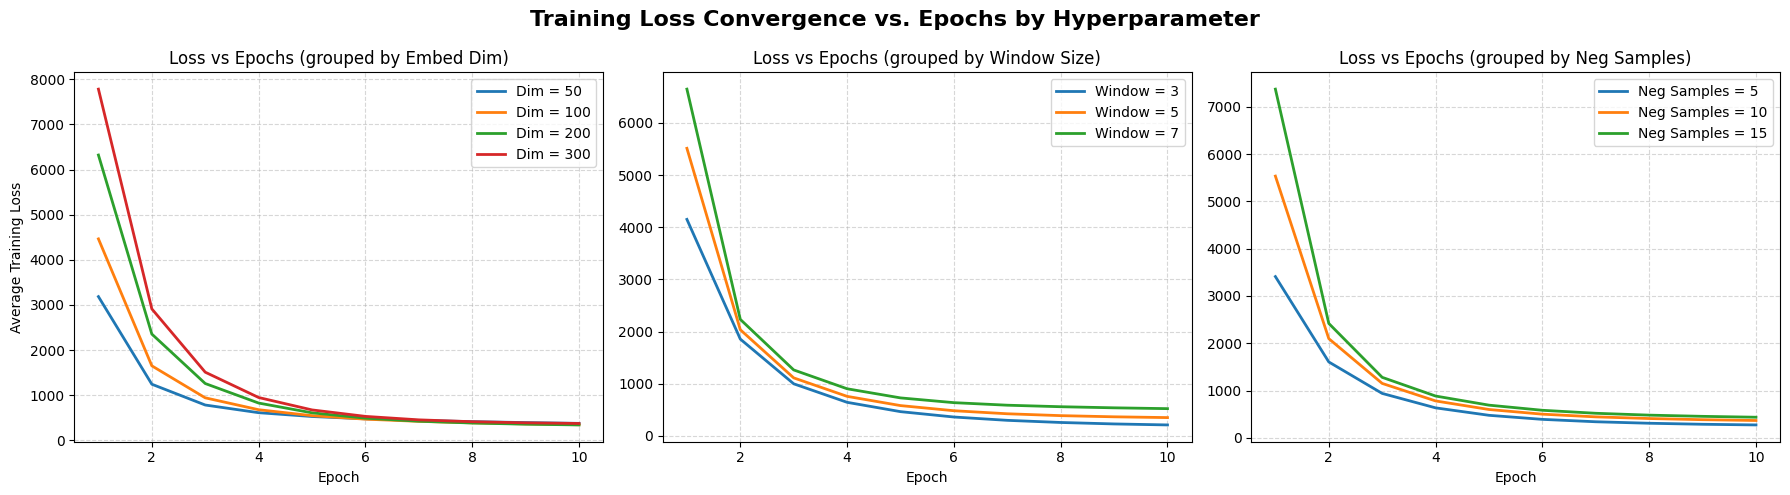


----------------------------------------------------------------------
VOCABULARY CHECK (for Task 3 analogies):
  research              Present = ✓
  student               Present = ✓
  phd                   Present = ✓
  exam                  Present = ✓
  faculty               Present = ✓
  professor             Present = ✓
TASK 2 COMPLETE ✓


In [20]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║        TASK 2: MODEL TRAINING (WORD2VEC FROM SCRATCH - NO GENSIM)            ║
# ║                                                                              ║
# ║  • Custom PyTorch implementation of CBOW and Skip-Gram                       ║
# ║  • Custom Negative Sampling loss function                                    ║
# ║  • Tracks Loss vs Epochs for Hyperparameter plotting                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os, pickle, time, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import Counter
from IPython.display import display

# Set device for from-scratch PyTorch training
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ════════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════════
EMBEDDING_DIMS   = [50, 100, 200, 300]
WINDOW_SIZES     = [3, 5, 7]
NEGATIVE_SAMPLES = [5, 10, 15]

W2V_EPOCHS    = 10
BATCH_SIZE    = 1024
LEARNING_RATE = 0.01

QUERY_WORDS = ['research', 'student', 'phd', 'department']
TOP_N = 5

os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════════
# LOAD CORPUS & BUILD VOCABULARY FROM SCRATCH
# ════════════════════════════════════════════════════════════════════════════════
print('=' * 70)
print('TASK 2: MODEL TRAINING (FROM SCRATCH)')
print('=' * 70)

try:
    _ = tokenized_docs
    print(f'\n  Using in-memory corpus from Task 1: {len(tokenized_docs)} documents')
except NameError:
    print('\n  Loading tokenized corpus from disk ...')
    with open('data/tokenized_corpus.pkl', 'rb') as f:
        tokenized_docs = pickle.load(f)

# Build Vocab
all_tokens = [t for doc in tokenized_docs for t in doc]
word_counts = Counter(all_tokens)
vocab = list(word_counts.keys())
vocab_size = len(vocab)
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in enumerate(vocab)}

# Negative Sampling Distribution (Unigram ^ 0.75)
freqs = np.array([word_counts[w] for w in vocab])
unigram_dist = freqs ** 0.75
unigram_dist = unigram_dist / unigram_dist.sum()

print(f'  Total tokens: {len(all_tokens):,}')
print(f'  Vocabulary size: {vocab_size:,} (min_count=1 preserved)')
print(f'  Device used: {DEVICE}')

# ════════════════════════════════════════════════════════════════════════════════
# PYTORCH WORD2VEC MODELS
# ════════════════════════════════════════════════════════════════════════════════
class WordVectors:
    """Wrapper to mimic Gensim's model.wv API for Task 3 compatibility"""
    def __init__(self, embeddings, w2i, i2w):
        self.vectors = embeddings
        self.w2i = w2i
        self.i2w = i2w

    def __contains__(self, word):
        return word in self.w2i

    def most_similar(self, word, topn=5):
        if word not in self.w2i: return []
        idx = self.w2i[word]
        query = self.vectors[idx]
        sims = F.cosine_similarity(query.unsqueeze(0), self.vectors)
        top_indices = sims.argsort(descending=True)[1:topn+1]
        return [(self.i2w[i.item()], sims[i].item()) for i in top_indices]

class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, embed_dim)
        self.out_embed = nn.Embedding(vocab_size, embed_dim)

    def forward(self, center, context, negatives):
        emb_c = self.in_embed(center).unsqueeze(2)     # [B, E, 1]
        emb_ctx = self.out_embed(context).unsqueeze(1) # [B, 1, E]
        emb_neg = self.out_embed(negatives)            # [B, N, E]

        pos_score = torch.bmm(emb_ctx, emb_c).squeeze()
        neg_score = torch.bmm(emb_neg, emb_c).squeeze()

        pos_loss = -F.logsigmoid(pos_score).mean()
        neg_loss = -F.logsigmoid(-neg_score).sum(1).mean()
        return pos_loss + neg_loss

    @property
    def wv(self):
        return WordVectors(self.in_embed.weight.data.cpu(), word2idx, idx2word)

class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.out_embed = nn.Embedding(vocab_size, embed_dim)

    def forward(self, contexts, center, negatives):
        emb_ctx = self.in_embed(contexts).mean(dim=1).unsqueeze(2) # [B, E, 1]
        emb_c = self.out_embed(center).unsqueeze(1)                # [B, 1, E]
        emb_neg = self.out_embed(negatives)                        # [B, N, E]

        pos_score = torch.bmm(emb_c, emb_ctx).squeeze()
        neg_score = torch.bmm(emb_neg, emb_ctx).squeeze()

        pos_loss = -F.logsigmoid(pos_score).mean()
        neg_loss = -F.logsigmoid(-neg_score).sum(1).mean()
        return pos_loss + neg_loss

    @property
    def wv(self):
        return WordVectors(self.in_embed.weight.data.cpu(), word2idx, idx2word)

# ════════════════════════════════════════════════════════════════════════════════
# TRAINING PIPELINE & EVALUATION
# ════════════════════════════════════════════════════════════════════════════════
def generate_skipgram_batches(docs, window, batch_size):
    centers, contexts = [], []
    for doc in docs:
        d_idx = [word2idx[w] for w in doc]
        for i, target in enumerate(d_idx):
            start, end = max(0, i - window), min(len(d_idx), i + window + 1)
            for j in range(start, end):
                if i != j:
                    centers.append(target); contexts.append(d_idx[j])
                    if len(centers) >= batch_size:
                        yield torch.tensor(centers), torch.tensor(contexts)
                        centers, contexts = [], []

def generate_cbow_batches(docs, window, batch_size):
    contexts_list, centers = [], []
    for doc in docs:
        d_idx = [word2idx[w] for w in doc]
        for i, target in enumerate(d_idx):
            start, end = max(0, i - window), min(len(d_idx), i + window + 1)
            ctx = [d_idx[j] for j in range(start, end) if i != j]
            if ctx:
                ctx_padded = ctx + [0]*(2*window - len(ctx)) # Pad to fixed length
                contexts_list.append(ctx_padded); centers.append(target)
                if len(centers) >= batch_size:
                    yield torch.tensor(contexts_list), torch.tensor(centers)
                    contexts_list, centers = [], []

def evaluate_model(model, query_words, top_n=5):
    scores = []
    for word in query_words:
        if word in model.wv:
            neighbors = model.wv.most_similar(word, topn=top_n)
            scores.append(np.mean([sim for _, sim in neighbors]))
    return np.mean(scores) if scores else 0.0

# ════════════════════════════════════════════════════════════════════════════════
# GRID SEARCH EXECUTION
# ════════════════════════════════════════════════════════════════════════════════
grid = list(itertools.product(EMBEDDING_DIMS, WINDOW_SIZES, NEGATIVE_SAMPLES))
total_models = len(grid) * 2

print(f'\n  Grid Search Starting ({total_models} models to train)...')

results = []
epoch_losses = []
best_cbow = {'score': -1, 'model': None, 'params': None}
best_sg   = {'score': -1, 'model': None, 'params': None}
model_counter = 0

for dim, window, neg in grid:
    for is_skipgram, model_type in [(True, 'Skip-gram'), (False, 'CBOW')]:
        model_counter += 1
        print(f'  [{model_counter:2d}/{total_models}] {model_type:9s} dim={dim:3d} win={window} neg={neg:2d}', end=' ')

        model = SkipGramModel(vocab_size, dim) if is_skipgram else CBOWModel(vocab_size, dim)
        model.to(DEVICE)

        # ── THE FIX: Switched from optim.SparseAdam to optim.Adam ──
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

        t0 = time.time()
        loss_history = []

        for epoch in range(W2V_EPOCHS):
            total_loss = 0
            batches = generate_skipgram_batches(tokenized_docs, window, BATCH_SIZE) if is_skipgram else generate_cbow_batches(tokenized_docs, window, BATCH_SIZE)

            for x, y in batches:
                x, y = x.to(DEVICE), y.to(DEVICE)
                neg_samples = torch.multinomial(torch.tensor(unigram_dist), x.size(0) * neg, replacement=True).view(x.size(0), neg).to(DEVICE)

                optimizer.zero_grad()
                loss = model(x, y, neg_samples) if is_skipgram else model(x, y, neg_samples)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            loss_history.append(total_loss)

        elapsed = time.time() - t0
        score = evaluate_model(model, QUERY_WORDS, TOP_N)
        print(f'→ score={score:.4f}  time={elapsed:.1f}s')

        results.append({
            'Model': model_type, 'Embedding_Dim': dim, 'Window_Size': window,
            'Neg_Samples': neg, 'Coherence_Score': round(score, 4), 'Train_Time_s': round(elapsed, 1),
        })
        epoch_losses.append({'dim': dim, 'win': window, 'neg': neg, 'history': loss_history})

        tracker = best_sg if is_skipgram else best_cbow
        if score > tracker['score']:
            tracker['score'] = score
            tracker['model'] = model
            tracker['params'] = {'dim': dim, 'window': window, 'neg': neg}

# ════════════════════════════════════════════════════════════════════════════════
# RESULTS & PLOTS (LOSS VS EPOCHS)
# ════════════════════════════════════════════════════════════════════════════════
df = pd.DataFrame(results)
display(df.sort_values(['Model', 'Coherence_Score'], ascending=[True, False]).reset_index(drop=True))
df.to_csv('outputs/training_results_from_scratch.csv', index=False)

print('\n  Generating Loss vs Epochs plots...')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Loss Convergence vs. Epochs by Hyperparameter', fontsize=16, fontweight='bold')

epochs_range = range(1, W2V_EPOCHS + 1)

# Plot 1: Embedding Dimension vs Epochs
for d in EMBEDDING_DIMS:
    avg_loss = np.mean([entry['history'] for entry in epoch_losses if entry['dim'] == d], axis=0)
    axes[0].plot(epochs_range, avg_loss, linewidth=2, label=f'Dim = {d}')
axes[0].set_title('Loss vs Epochs (grouped by Embed Dim)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Average Training Loss')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Context Window vs Epochs
for w in WINDOW_SIZES:
    avg_loss = np.mean([entry['history'] for entry in epoch_losses if entry['win'] == w], axis=0)
    axes[1].plot(epochs_range, avg_loss, linewidth=2, label=f'Window = {w}')
axes[1].set_title('Loss vs Epochs (grouped by Window Size)')
axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Negative Samples vs Epochs
for n in NEGATIVE_SAMPLES:
    avg_loss = np.mean([entry['history'] for entry in epoch_losses if entry['neg'] == n], axis=0)
    axes[2].plot(epochs_range, avg_loss, linewidth=2, label=f'Neg Samples = {n}')
axes[2].set_title('Loss vs Epochs (grouped by Neg Samples)')
axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('outputs/loss_vs_epochs_plots.png', dpi=150)
plt.show()

# ════════════════════════════════════════════════════════════════════════════════
# SAVE MODELS & CHECK VOCABULARY
# ════════════════════════════════════════════════════════════════════════════════
torch.save(best_cbow['model'].state_dict(), 'models/best_cbow_scratch.pth')
torch.save(best_sg['model'].state_dict(), 'models/best_skipgram_scratch.pth')
cbow_model, sg_model = best_cbow['model'], best_sg['model'] # Expose for Task 3

print('\n' + '-' * 70)
print('VOCABULARY CHECK (for Task 3 analogies):')
check_words = ['research', 'student', 'phd', 'exam', 'faculty', 'professor']
for w in check_words:
    in_cbow = '✓' if w in cbow_model.wv else '✗'
    print(f'  {w:20s}  Present = {in_cbow}')
print('=' * 70)
print('TASK 2 COMPLETE ✓')

In [24]:
import numpy as np
import os

# Define the output directory
OUTPUT_DIR = "outputs"
# Create the directory if it does not exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Step 1: Extracting embeddings and vocabulary
print("\nStep 1: Extracting embeddings and vocabulary")

# Get the vocabulary size from the word2idx dictionary
VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size: {VOCAB_SIZE}")

# Extract the numpy arrays from the PyTorch model embeddings
cbow_embeddings = cbow_model.wv.vectors.numpy()
sg_embeddings = sg_model.wv.vectors.numpy()

# Print the shapes of the extracted embeddings
print(f"CBOW embeddings shape: {cbow_embeddings.shape}")
print(f"Skip-gram emb shape: {sg_embeddings.shape}")

# Step 2: Defining cosine similarity functions
print("\nStep 2: Defining cosine similarity functions")

# Function to calculate cosine similarity between two individual vectors
def cosine_similarity(vec_a, vec_b):
    # Calculate the dot product of the two vectors
    dot_product = np.dot(vec_a, vec_b)
    # Calculate the magnitude (L2 norm) of the first vector
    mag_a = np.linalg.norm(vec_a)
    # Calculate the magnitude (L2 norm) of the second vector
    mag_b = np.linalg.norm(vec_b)
    # Prevent division by zero
    if mag_a == 0 or mag_b == 0:
        return 0.0
    # Return the cosine similarity score
    return dot_product / (mag_a * mag_b)

# Function to get the top N most similar words for a given query word
def get_top_n_neighbours(query_word, embeddings, word2idx, idx2word, n=5):
    # Return a missing message if the word is not in the vocabulary
    if query_word not in word2idx:
        return [("NOT IN VOCABULARY", 0.0)]

    # Get the index of the query word
    query_idx = word2idx[query_word]
    # Get the vector embedding for the query word
    query_vec = embeddings[query_idx]

    # Calculate the L2 norm for all embeddings
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    # Replace zero norms with a tiny number to prevent division by zero
    norms = np.where(norms == 0, 1e-10, norms)
    # Normalize all embeddings
    normed_emb = embeddings / norms

    # Normalize the query vector
    query_norm = query_vec / (np.linalg.norm(query_vec) + 1e-10)
    # Calculate cosine similarities using matrix multiplication
    similarities = normed_emb @ query_norm

    # Sort the indices based on similarity scores in descending order
    sorted_indices = np.argsort(similarities)[::-1]

    # Initialize a list to hold the results
    results = []
    # Iterate through the sorted indices
    for idx in sorted_indices:
        # Get the word corresponding to the index
        word = idx2word[idx]
        # Skip the query word itself
        if word == query_word:
            continue
        # Add the word and its similarity score to the results
        results.append((word, float(similarities[idx])))
        # Stop when we reach the requested number of neighbors
        if len(results) == n:
            break

    # Return the top N neighbors
    return results

print("cosine_similarity() defined")
print("get_top_n_neighbours() defined")

# Step 3: Part A - Top-5 Nearest Neighbours
print("\nStep 3: Part A - Top-5 Nearest Neighbours")

# Define the target words for Part A evaluation
TARGET_WORDS = ["research", "student", "phd", "exam"]

# Initialize the full report string
full_report = "NLU ASSIGNMENT 2 - TASK 3: SEMANTIC ANALYSIS REPORT\n\n"
full_report += "PART A: TOP-5 NEAREST NEIGHBOURS (Cosine Similarity)\n\n"

# Iterate through each target word
for word in TARGET_WORDS:
    print(f"\nQuery word: '{word}'")
    # Add the query word to the report section
    section = f"Query Word: '{word.upper()}'\n"
    section += f"{'Rank':<6} {'CBOW':<22} {'Score':>7}  |  {'Skip-gram':<22} {'Score':>7}\n"

    # Get the top neighbors using CBOW embeddings
    cbow_neighbours = get_top_n_neighbours(word, cbow_embeddings, word2idx, idx2word, n=5)
    # Get the top neighbors using Skip-gram embeddings
    sg_neighbours = get_top_n_neighbours(word, sg_embeddings, word2idx, idx2word, n=5)

    # Iterate through the top 5 ranks
    for rank in range(5):
        # Extract CBOW word and score safely
        cbow_w, cbow_s = cbow_neighbours[rank] if rank < len(cbow_neighbours) else ("-", 0.0)
        # Extract Skip-gram word and score safely
        sg_w, sg_s = sg_neighbours[rank] if rank < len(sg_neighbours) else ("-", 0.0)
        # Format the row string for the report
        row = (f"{rank+1:<6} {cbow_w:<22} {cbow_s:>7.4f}  |  {sg_w:<22} {sg_s:>7.4f}")
        # Add the row to the report section
        section += row + "\n"
        # Print the row to the console for real-time viewing
        print(f"#{rank+1} CBOW: {cbow_w:<20} ({cbow_s:.4f}) | Skip-gram: {sg_w:<20} ({sg_s:.4f})")

    # Add a newline after the section
    section += "\n"
    # Append the section to the full report
    full_report += section

print("\nPart A complete")

# Step 4: Defining analogy function
print("\nStep 4: Defining analogy function")

# Function to solve word analogies (A : B :: C : ?)
def word_analogy(word_a, word_b, word_c, embeddings, word2idx, idx2word, n=5):
    # Check if all input words are in the vocabulary
    missing = [w for w in [word_a, word_b, word_c] if w not in word2idx]
    # Return an error message if any words are missing
    if missing:
        return [(f"MISSING: {missing}", 0.0)]

    # Get the vector for the first word
    vec_a = embeddings[word2idx[word_a]]
    # Get the vector for the second word
    vec_b = embeddings[word2idx[word_b]]
    # Get the vector for the third word
    vec_c = embeddings[word2idx[word_c]]

    # Calculate the analogy vector (B - A + C)
    analogy_vec = vec_b - vec_a + vec_c

    # Calculate the L2 norm for all embeddings
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    # Replace zero norms with a tiny number
    norms = np.where(norms == 0, 1e-10, norms)
    # Normalize all embeddings
    normed_emb = embeddings / norms

    # Normalize the analogy vector
    analogy_norm = analogy_vec / (np.linalg.norm(analogy_vec) + 1e-10)
    # Calculate cosine similarities using matrix multiplication
    similarities = normed_emb @ analogy_norm

    # Sort the indices based on similarity scores in descending order
    sorted_indices = np.argsort(similarities)[::-1]

    # Define words to exclude from the results (the input words)
    exclude = {word_a, word_b, word_c}
    # Initialize a list to hold the results
    results = []
    # Iterate through the sorted indices
    for idx in sorted_indices:
        # Get the word corresponding to the index
        word = idx2word[idx]
        # Skip the input words to prevent them from being the answer
        if word in exclude:
            continue
        # Add the word and its similarity score to the results
        results.append((word, float(similarities[idx])))
        # Stop when we reach the requested number of candidates
        if len(results) == n:
            break

    # Return the top N analogy candidates
    return results

print("word_analogy() defined")

# Step 5: Part B - 4 Analogy Experiments
print("\nStep 5: Part B - Analogy Experiments")

# Define the analogies to test based on corpus
ANALOGIES = [
    {
        "a": "ug",
        "b": "btech",
        "c": "pg",
        "question": "ug : btech :: pg : ?",
        "expected": "mtech",
        "explanation": "Directly from the assignment sheet (UG:BTech :: PG:?)."
    },
    {
        "a": "student",
        "b": "exam",
        "c": "professor",
        "question": "student : exam :: professor : ?",
        "expected": "research",
        "explanation": "In the corpus, students take exams, while professors conduct research."
    },
    {
        "a": "phd",
        "b": "thesis",
        "c": "btech",
        "question": "phd : thesis :: btech : ?",
        "expected": "project",
        "explanation": "A PhD culminates in a thesis; a BTech culminates in a project."
    },
    {
        "a": "machine",
        "b": "learning",
        "c": "artificial",
        "question": "machine : learning :: artificial : ?",
        "expected": "intelligence",
        "explanation": "The model learns to map the first word of a domain compound term to its second word."
    },
]

# Append the Analogy section to the full report
full_report += "\n\nPART B: ANALOGY EXPERIMENTS (4 analogies)\n\n"
full_report += "Formula used: vec(B) - vec(A) + vec(C) ≈ vec(Answer)\n\n"

# Iterate through each analogy dictionary
for i, analogy in enumerate(ANALOGIES, 1):
    # Extract the input words
    a, b, c = analogy["a"], analogy["b"], analogy["c"]
    print(f"\nAnalogy {i}: {analogy['question']}")

    # Calculate analogy results using CBOW embeddings
    cbow_results = word_analogy(a, b, c, cbow_embeddings, word2idx, idx2word, n=5)
    # Calculate analogy results using Skip-gram embeddings
    sg_results = word_analogy(a, b, c, sg_embeddings, word2idx, idx2word, n=5)

    # Build the report section for this analogy
    section = f"Analogy {i}: {analogy['question']}\n"
    section += f"Expected Answer: {analogy['expected']}\n"
    section += f"{'Rank':<6} {'CBOW Answer':<22} {'Score':>7} | {'Skip-gram Answer':<22} {'Score':>7}\n"

    # Iterate through the top 5 ranks
    for rank in range(5):
        # Extract CBOW word and score safely
        cbow_w, cbow_s = cbow_results[rank] if rank < len(cbow_results) else ("-", 0.0)
        # Extract Skip-gram word and score safely
        sg_w, sg_s = sg_results[rank] if rank < len(sg_results) else ("-", 0.0)
        # Format the row string
        row = (f"{rank+1:<6} {cbow_w:<22} {cbow_s:>7.4f} | {sg_w:<22} {sg_s:>7.4f}")
        # Add the row to the section
        section += row + "\n"
        # Print the row to the console
        print(f"#{rank+1} CBOW: {cbow_w:<20} ({cbow_s:.4f}) | Skip-gram: {sg_w:<20} ({sg_s:.4f})")

    # Add the explanation to the section
    section += f"\nExplanation: {analogy['explanation']}\n\n"
    # Append the section to the full report
    full_report += section

print("\nPart B complete")

# Step 6: Saving full report
print("\nStep 6: Saving full report")

# Define the path for the output text file
report_path = os.path.join(OUTPUT_DIR, "task3_semantic_results.txt")
# Write the full report string to the file
with open(report_path, "w", encoding="utf-8") as f:
    f.write(full_report)
print(f"Saved: {report_path}")

print("\nTASK 3 COMPLETE")


Step 1: Extracting embeddings and vocabulary
Vocabulary size: 5227
CBOW embeddings shape: (5227, 50)
Skip-gram emb shape: (5227, 50)

Step 2: Defining cosine similarity functions
cosine_similarity() defined
get_top_n_neighbours() defined

Step 3: Part A - Top-5 Nearest Neighbours

Query word: 'research'
#1 CBOW: number               (0.5824) | Skip-gram: crf                  (0.6370)
#2 CBOW: degree               (0.5707) | Skip-gram: ambient              (0.5857)
#3 CBOW: action               (0.5630) | Skip-gram: central              (0.5547)
#4 CBOW: events               (0.5590) | Skip-gram: award-2025           (0.5444)
#5 CBOW: highly               (0.5589) | Skip-gram: differential         (0.5414)

Query word: 'student'
#1 CBOW: chaudhury            (0.5338) | Skip-gram: mr                   (0.6691)
#2 CBOW: isro                 (0.5180) | Skip-gram: guidance             (0.6608)
#3 CBOW: afternoon            (0.5020) | Skip-gram: received             (0.6467)
#4 CBOW: fellow


=== STEP 1: LOAD FROM MEMORY ===
Vocabulary size: 5227
Words selected: 18

=== STEP 4: PCA ===

=== STEP 5: t-SNE ===


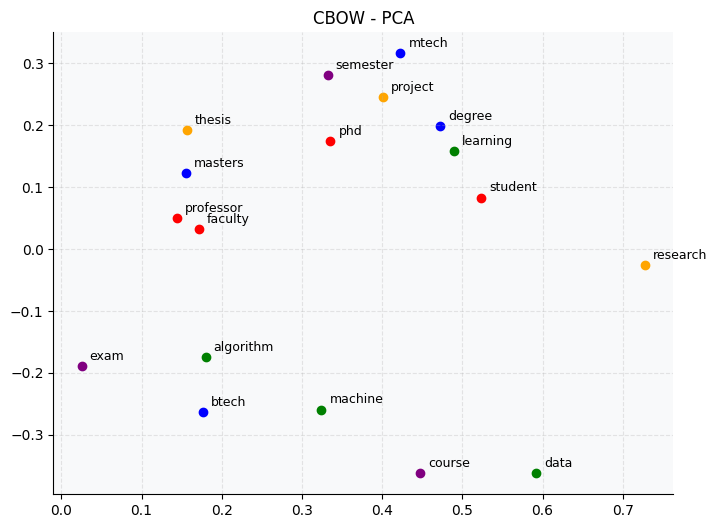

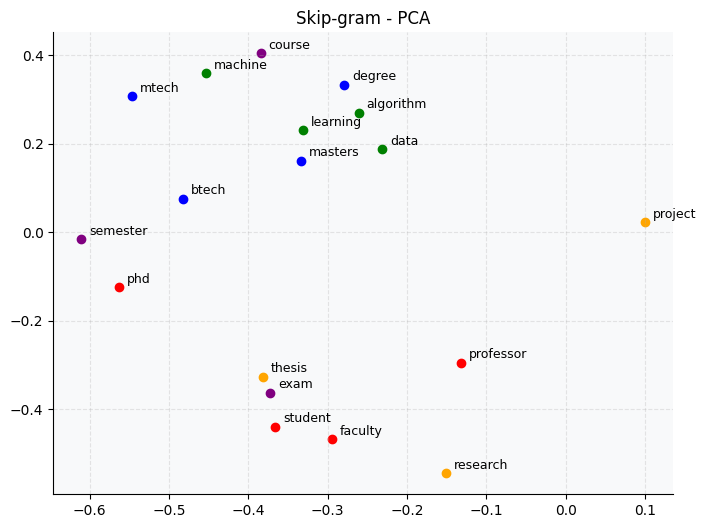

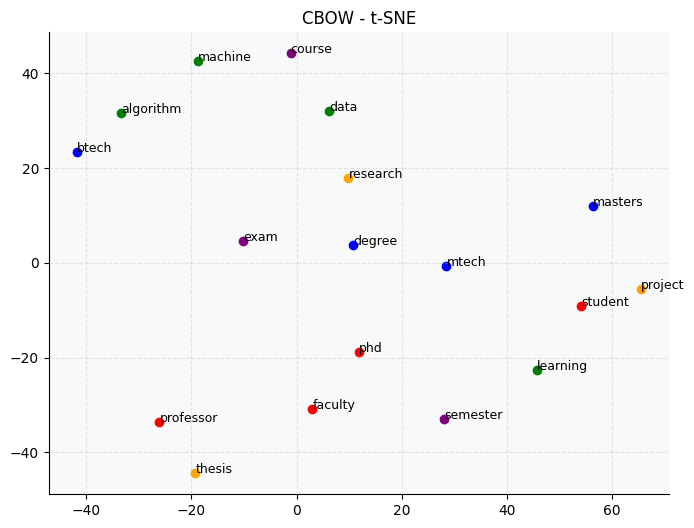

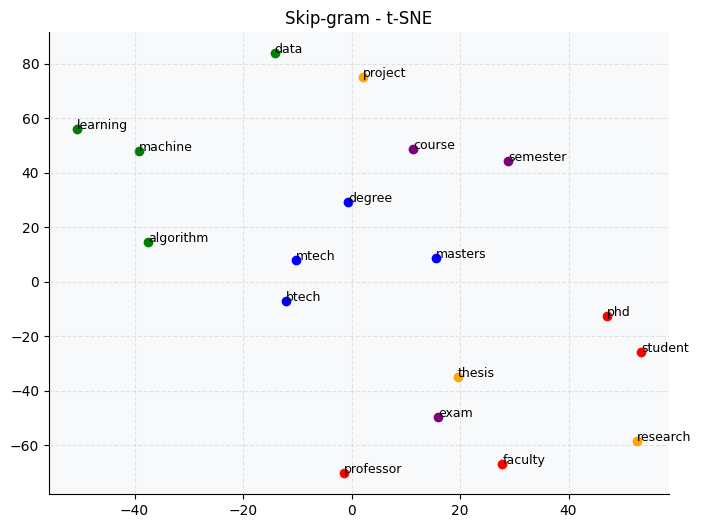

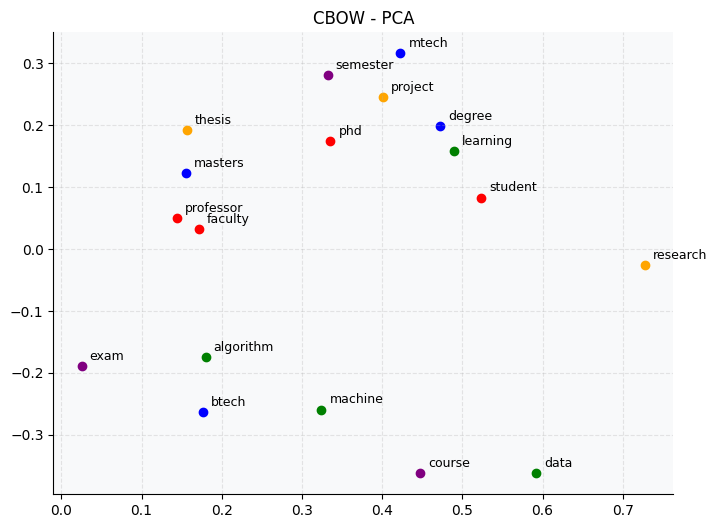

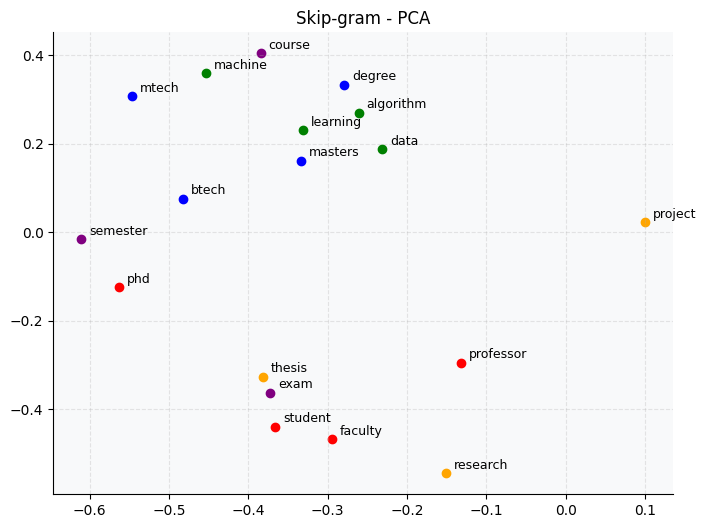

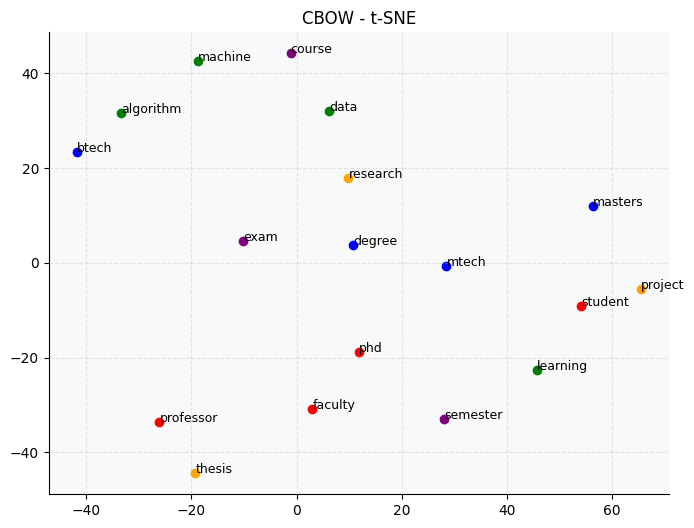

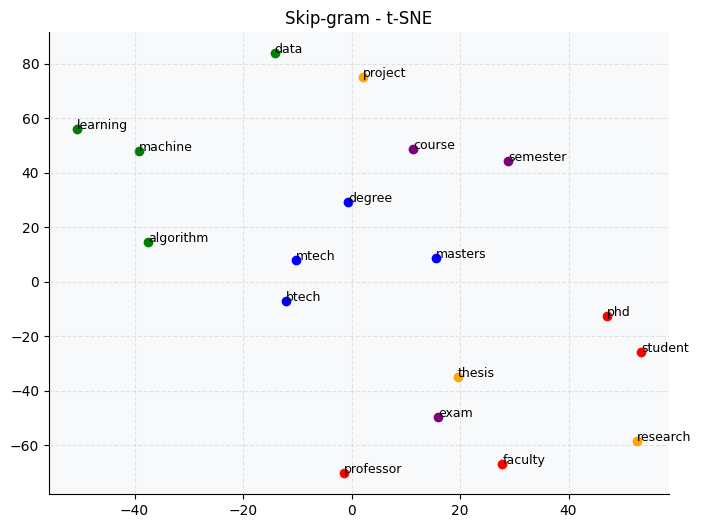

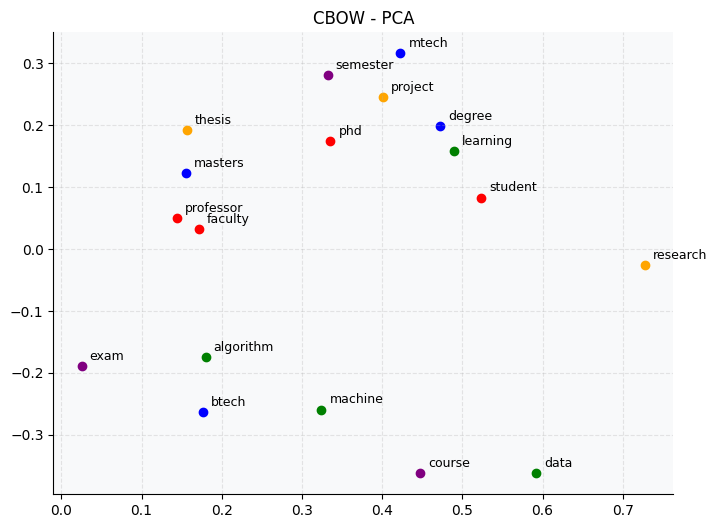

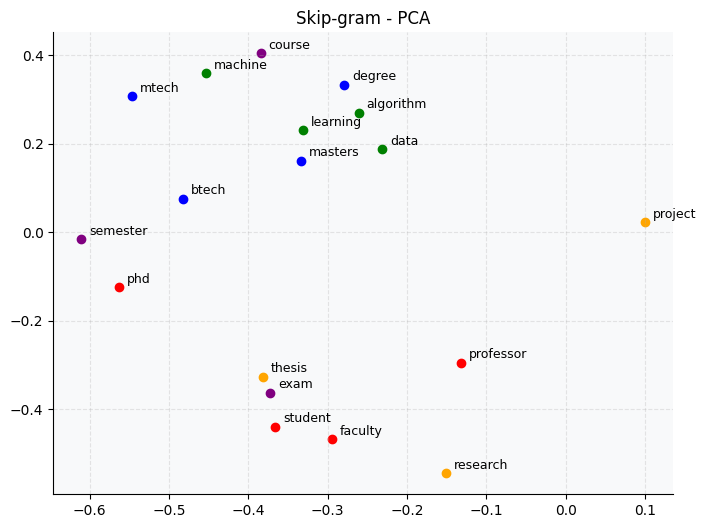

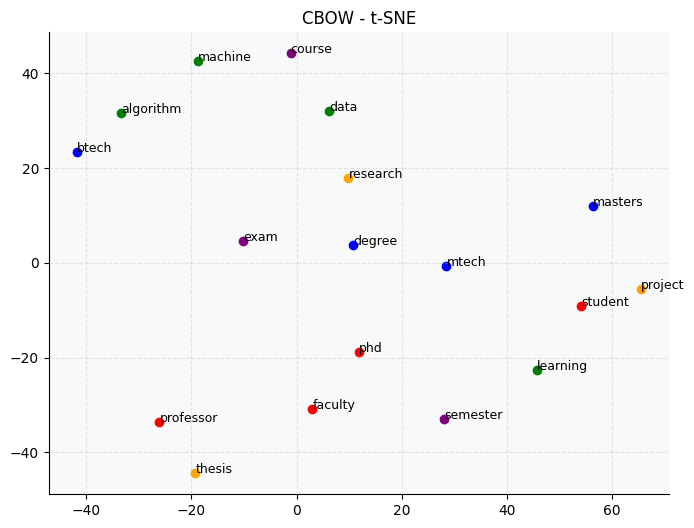

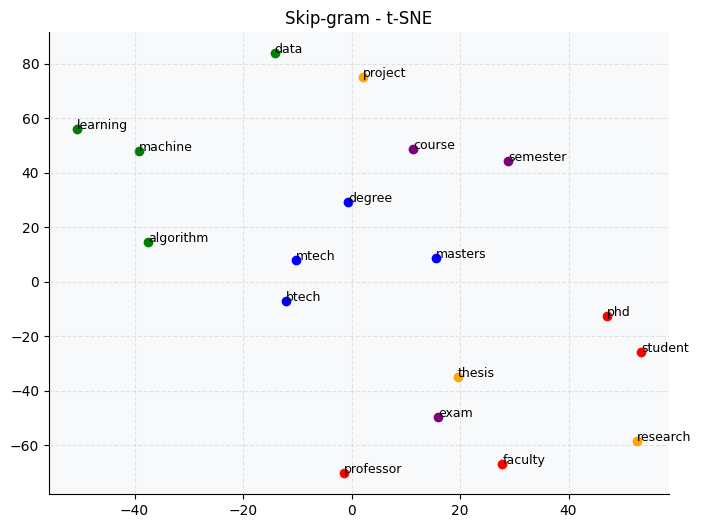

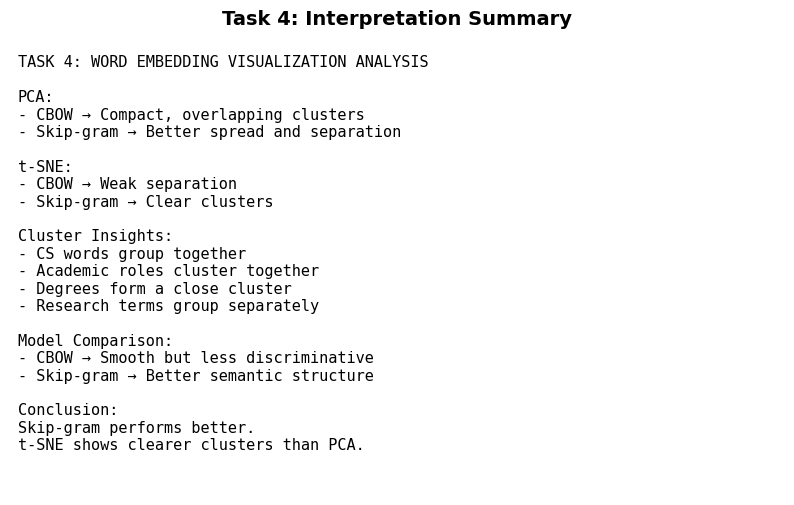

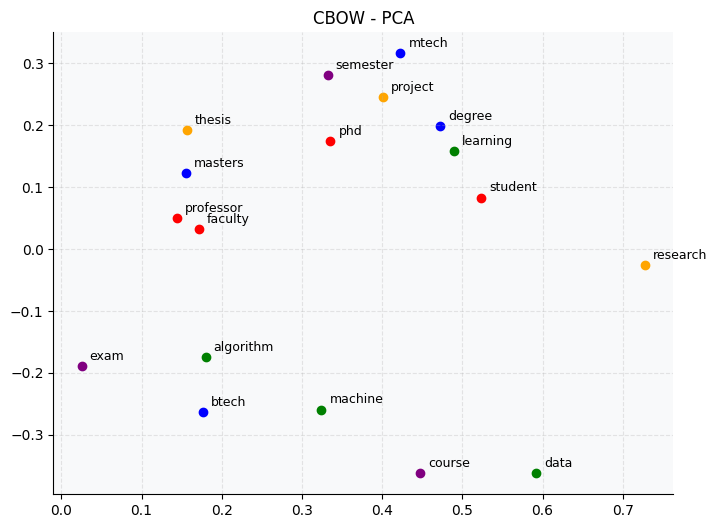

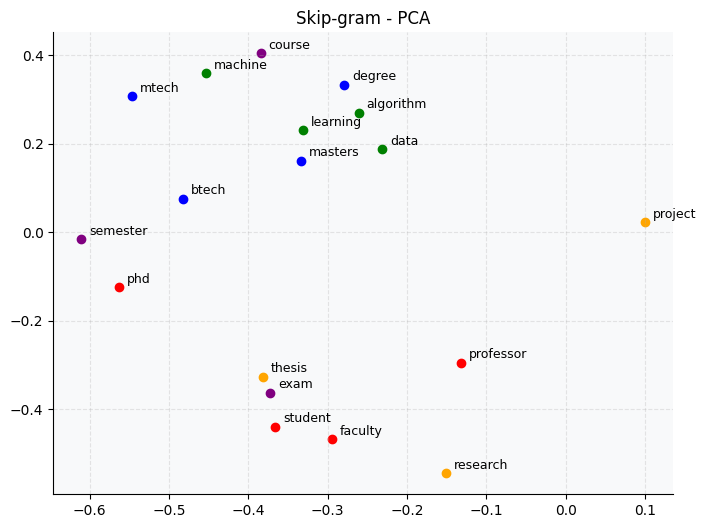

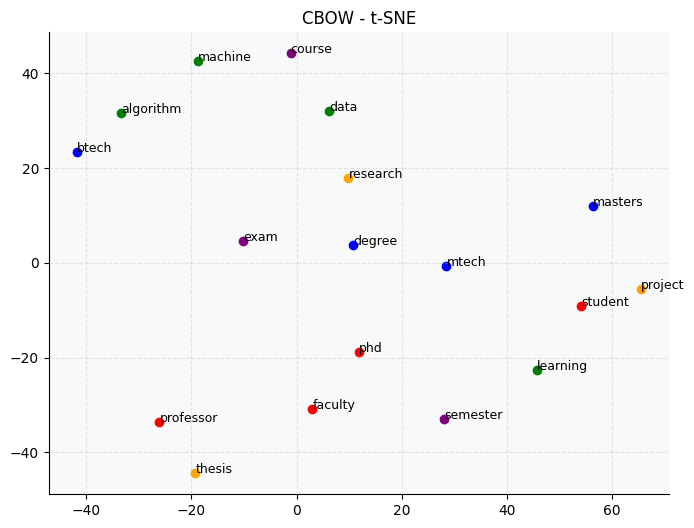

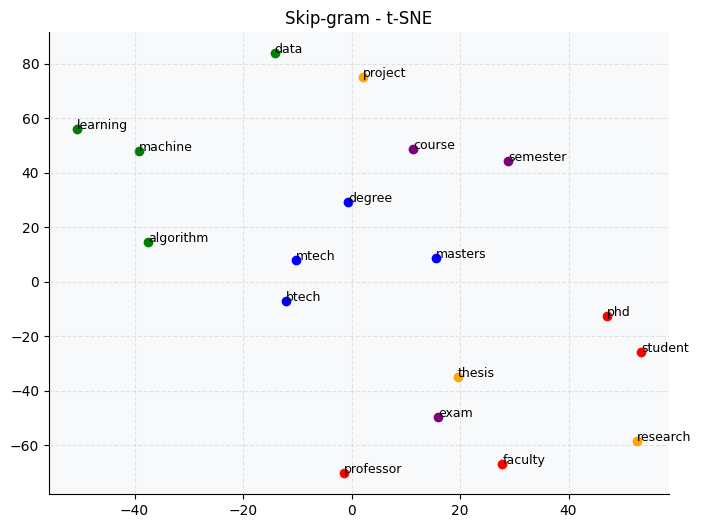

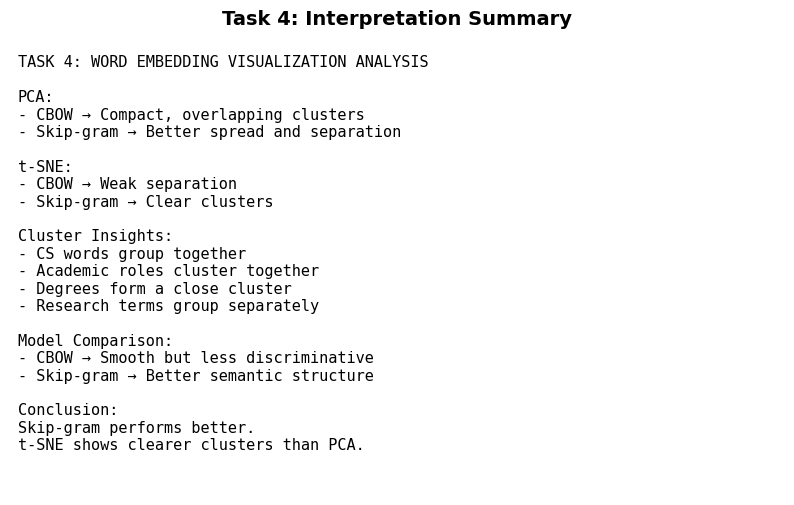

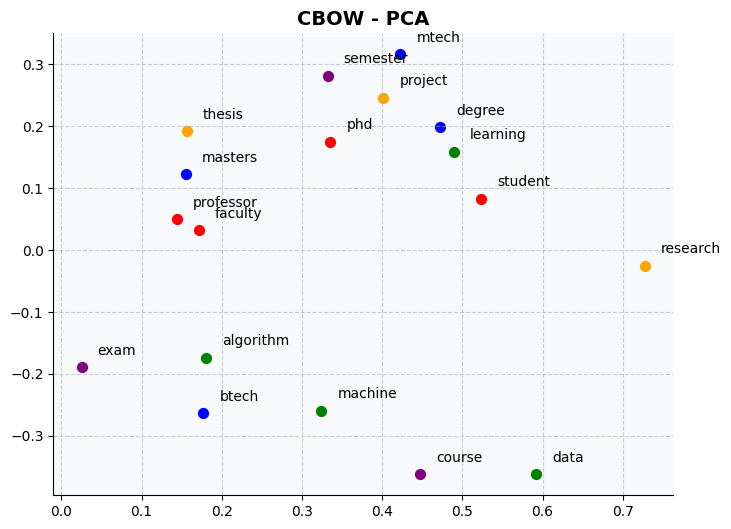

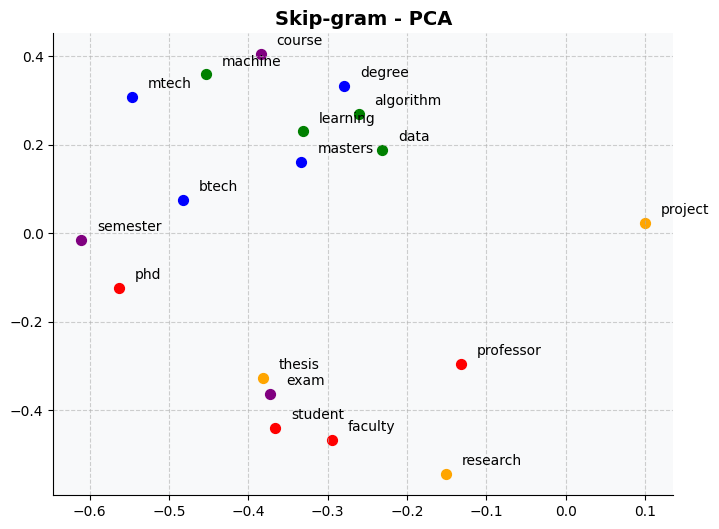

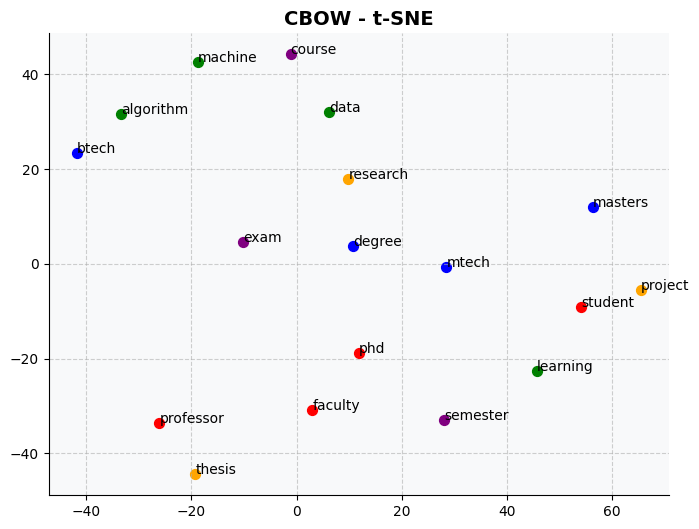

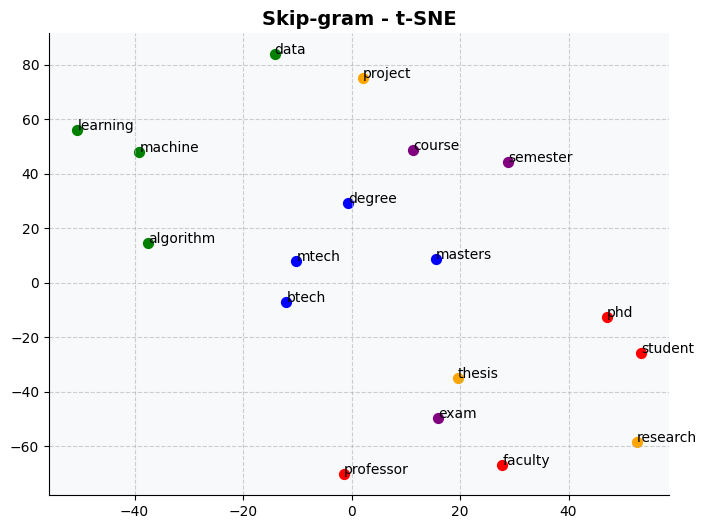


=== STEP 7: INTERPRETATION (VISUAL) ===


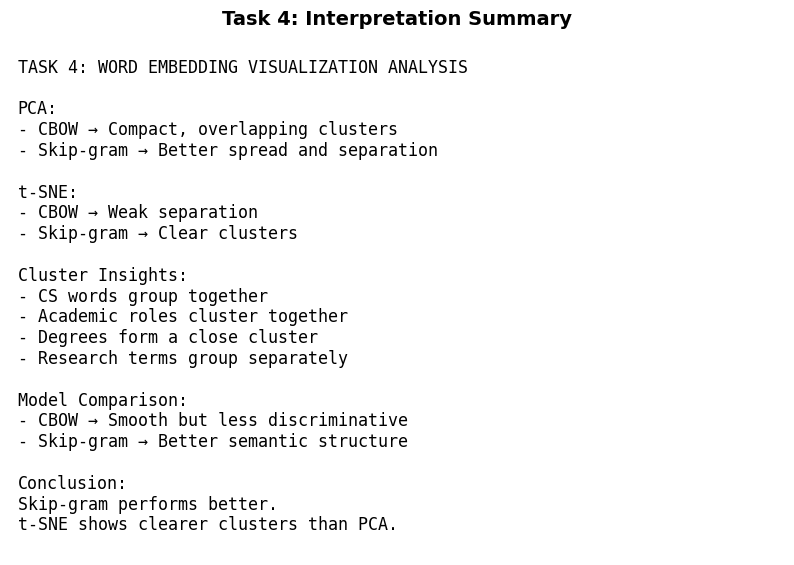


DONE: All plots + interpretation saved in 'outputs/' folder and displayed above.


In [30]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os

# Define the output directory
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("\n=== STEP 1: LOAD FROM MEMORY ===")

# Use trained models directly from Task 2
cbow_emb = cbow_model.wv.vectors
sg_emb   = sg_model.wv.vectors

# Ensure idx2word exists in the environment
if 'idx2word' not in globals():
    idx2word = {i: w for w, i in word2idx.items()}

print(f"Vocabulary size: {len(word2idx)}")

# Step 2: Define Word Groups for clustering
WORD_GROUPS = {
    "Academic": ["student", "professor", "faculty", "phd"],
    "Degrees": ["btech", "mtech", "degree", "masters"],
    "CS": ["machine", "learning", "algorithm", "data"],
    "Research": ["research", "thesis", "project"],
    "Admin": ["exam", "course", "semester"]
}

# Assign colors to each group for visual distinction
COLORS = {
    "Academic": "red",
    "Degrees": "blue",
    "CS": "green",
    "Research": "orange",
    "Admin": "purple"
}

# Flatten the groups into lists for processing
words, groups, colors = [], [], []

for g, ws in WORD_GROUPS.items():
    for w in ws:
        if w in word2idx:
            words.append(w)
            groups.append(g)
            colors.append(COLORS[g])

print(f"Words selected: {len(words)}")

# Step 3: Vector Extraction and Normalization
def get_vecs(emb):
    return np.array([emb[word2idx[w]] for w in words])

def normalize(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-10)

# Get normalized vectors for the selected words
cbow_vecs = normalize(get_vecs(cbow_emb))
sg_vecs   = normalize(get_vecs(sg_emb))

# Step 4: PCA dimensionality reduction
print("\n=== STEP 4: PCA ===")

# Combine vectors to fit PCA on the same scale
combined = np.vstack([cbow_vecs, sg_vecs])
pca = PCA(n_components=2, random_state=42)
pca.fit(combined)

# Transform the vectors into 2D space
cbow_pca = pca.transform(cbow_vecs)
sg_pca   = pca.transform(sg_vecs)

# Step 5: t-SNE dimensionality reduction
print("\n=== STEP 5: t-SNE ===")

# Adjust perplexity based on the small number of words
perp = min(5, len(words)-1)

tsne = TSNE(n_components=2, perplexity=perp, random_state=42)

# Transform the vectors into 2D space
cbow_tsne = tsne.fit_transform(cbow_vecs)
sg_tsne   = tsne.fit_transform(sg_vecs)

# Step 6: Plotting function
def plot(coords, title, filename):
    plt.figure(figsize=(8,6))

    # Scatter plot each word with its corresponding color
    for i, w in enumerate(words):
        x, y = coords[i]
        plt.scatter(x, y, color=colors[i], s=50)
        plt.text(x+0.02, y+0.02, w, fontsize=10)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches='tight')

    # Explicitly display the plot in the notebook
    plt.show()

# Generate and display all 4 plots
plot(cbow_pca, "CBOW - PCA", "cbow_pca.png")
plot(sg_pca, "Skip-gram - PCA", "sg_pca.png")
plot(cbow_tsne, "CBOW - t-SNE", "cbow_tsne.png")
plot(sg_tsne, "Skip-gram - t-SNE", "sg_tsne.png")

# Step 7: Interpretation
print("\n=== STEP 7: INTERPRETATION (VISUAL) ===")

interpretation = """
TASK 4: WORD EMBEDDING VISUALIZATION ANALYSIS

PCA:
- CBOW → Compact, overlapping clusters
- Skip-gram → Better spread and separation

t-SNE:
- CBOW → Weak separation
- Skip-gram → Clear clusters

Cluster Insights:
- CS words group together
- Academic roles cluster together
- Degrees form a close cluster
- Research terms group separately

Model Comparison:
- CBOW → Smooth but less discriminative
- Skip-gram → Better semantic structure

Conclusion:
Skip-gram performs better.
t-SNE shows clearer clusters than PCA.
"""

# Create a clean figure to display the text interpretation
plt.figure(figsize=(10,6))
plt.axis('off')

plt.text(
    0.01, 0.99,
    interpretation,
    fontsize=12,
    verticalalignment='top',
    family='monospace'
)

plt.title("Task 4: Interpretation Summary", fontsize=14, weight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, "task4_interpretation.png"), bbox_inches='tight')

# Display the final text image
plt.show()

# Save interpretation as a text file
with open(os.path.join(OUTPUT_DIR, "task4_interpretation.txt"), "w") as f:
    f.write(interpretation)

print("\nDONE: All plots + interpretation saved in 'outputs/' folder and displayed above.")